In [3]:
from queue import PriorityQueue
from math import sqrt
import random
import time

print("hello")

class Graph:
    def __init__(self, num_of_vertices):
        self.v = num_of_vertices
        # edges is a 2d array of the "cost" to travel from node i to node j
        self.edges = [[-1 for j in range(num_of_vertices)] for i in range(num_of_vertices)]
        # nodeCoords is an array containing the longitudal and latitudal coordinates
        self.nodeCoords = [(0,0) for i in range(num_of_vertices)]
        # visited is an array containing the nodes assessed throughout the pathfinding process
        self.visited = []

    def add_edge(self, i, j, trafficLevel=None, speedLimit=None):
        if not trafficLevel or trafficLevel < 1 or trafficLevel > 2:
          trafficLevel = 1
        if not speedLimit or speedLimit not in {40, 50, 60, 70, 80}:
          speedLimit = 50
        # 1 unit on the coordinate plane accounts for 2 kms
        distance = self.euclidean(self.nodeCoords[i],self.nodeCoords[j])*2
        cost = distance/speedLimit
        cost = cost*trafficLevel
        self.edges[i][j] = cost
        self.edges[j][i] = cost
        return cost

    def add_node_coord(self, u, coord):
        self.nodeCoords[u] = coord
      
    def euclidean(self, p, q):
        return sqrt((q[0]-p[0])**2 + (q[1]-p[1])**2)
    
    def manhattan(self, p, q):
        return abs(q[0]-p[0]) + abs(q[1]-p[1])

    # Traces the optimal path with cameFrom
    def reconstruct_path(self, cameFrom, current):
        total_path = [current]
        while current in cameFrom:           
            current = cameFrom[current]
            total_path.append(current)
            
        return total_path
            

    def a_star(self, start_vertex, end_vertex, isDijkstra=False):

        start = time.time()
        gScore = {v:float('inf') for v in range(self.v)}
        gScore[start_vertex] = 0
        fScore =  {v:float('inf') for v in range(self.v)}
        fScore[start_vertex] = 0
        visitedNeighbors = []
        cameFrom = {v:-1 for v in range(self.v)}

        pq = PriorityQueue()
        pq.put((0, start_vertex))
        pqSet = {start_vertex: True}

        while not pq.empty():
            # Get the next node with the lowest f score
            f, current_vertex = pq.get()
            del pqSet[current_vertex]
            self.visited.append(current_vertex)

            # If the current node meets the destination node, return
            if current_vertex == end_vertex:
                end = time.time()
                return [self.reconstruct_path(cameFrom, current_vertex), fScore, visitedNeighbors, end - start]

            for neighbor in range(self.v):
                cost = self.edges[current_vertex][neighbor]
                if cost != -1:
                    visitedNeighbors.append(current_vertex)
                    tentative_gScore = gScore[current_vertex] + cost
                    
                    # Take current path if it is better than any previous path to neighbor
                    if tentative_gScore < gScore[neighbor]:
                        hScore = 0 if isDijkstra else self.manhattan(self.nodeCoords[current_vertex], self.nodeCoords[end_vertex])*2/80
                        cameFrom[neighbor] = current_vertex
                        gScore[neighbor] = tentative_gScore
                        fScore[neighbor] = tentative_gScore + hScore

                        if neighbor not in pqSet:
                            pq.put((tentative_gScore + hScore, neighbor))
                            pqSet[neighbor] = True

hello


In [4]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pylab
def plot_graph(edges, nodes, path, visitedNeighbors):
  node_size = 1000
  largeGraph = len(edges) > 50
  if largeGraph:
    node_size = 500
  G = nx.DiGraph()
  color_map=["white"]*len(nodes)
  for node in visitedNeighbors:
    color_map[node] = "pink"
  for node in path[:-1]:
    color_map[node] = "lightgreen" 
  for node in nodes:
    pos = node[1:][0]
    G.add_node(node[0], pos=pos)
  for edge in edges:
    G.add_edges_from([edge[:2]], weight=edge[2])
  red_edges = []
  for i in  range(len(path)-1):
    red_edges.append((path[i],path[i+1]))
    red_edges.append((path[i+1],path[i]))

  edge_labels=dict([((u,v,),d['weight']) for u,v,d in G.edges(data=True)])
  edge_colors = ['lightgray' if not edge in red_edges else 'green' for edge in G.edges()]
  plt.figure(1,figsize=(11,11)) 
  if not largeGraph:
    nx.draw_networkx_edge_labels(G,nx.get_node_attributes(G, 'pos'),edge_labels=edge_labels)
  nx.draw(G,nx.get_node_attributes(G, 'pos'), edgecolors="black", arrows=False, with_labels=True,node_color=color_map, node_size=node_size,edge_color=edge_colors, width=5)
  
  plt.show()

In [5]:
def find_shortest_path(edges, nodes, startNode, endNode):
  g = Graph(len(edges))
  edges_with_weights = []
  for node in nodes:
      g.add_node_coord(*node)
  for edge in edges:
      weight = "%.2f" % g.add_edge(*edge)
      edges_with_weights.append([*edge[:2],weight])

  a_star_result = g.a_star(startNode,endNode)
  dijkstra_result = g.a_star(startNode,endNode,True)
  print("A-star time: "+str(a_star_result[3])+" seconds")
  print("Dijkstra time: "+str(dijkstra_result[3])+" seconds")
  print("A-star visited nodes: "+str(len(set(a_star_result[2]))))
  print("Dijkstra visted nodes: "+str(len(set(dijkstra_result[2]))))

  plot_graph(edges_with_weights, nodes, a_star_result[0], a_star_result[2])
  plot_graph(edges_with_weights, nodes, dijkstra_result[0], dijkstra_result[2])

A-star time: 0.0003399848937988281 seconds
Dijkstra time: 0.0003235340118408203 seconds
A-star visited nodes: 18
Dijkstra visted nodes: 24


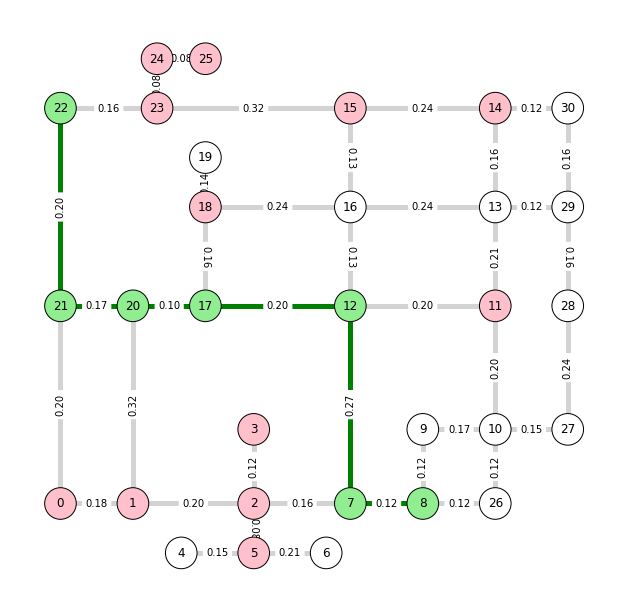

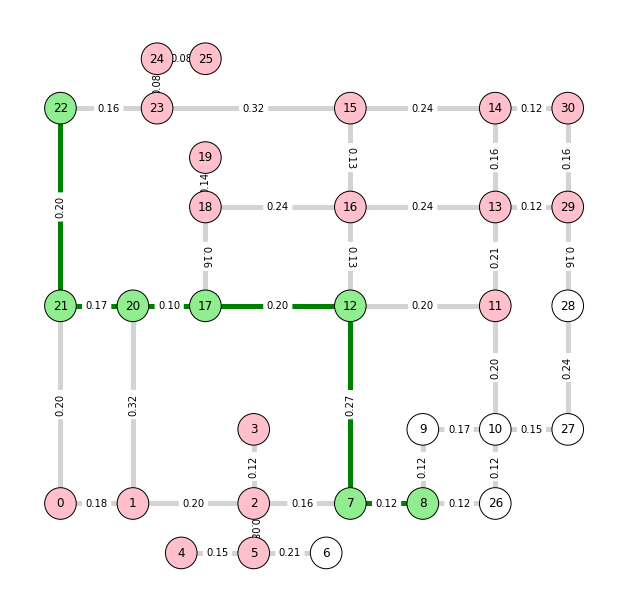

In [6]:
# Small road network example
# i, j, trafficLevel (default: 1), speedLimit (default: 50), 
edges = [
    [0,1,1.5,None],
    [0,21,None,80],
    [1,2,None,None],
    [1,20,None,None],
    [2,3,None,None],
    [2,5,None,None],
    [5,4,None,40],
    [5,6,1.4,40],
    [2,7,None,None],
    [7,8,None,None],
    [7,12,None,60],
    [8,26,None,None],
    [8,9,None,None],
    [9,10,1.4,None],
    [26,10,None,None],
    [10,11,None,None],
    [11,12,None,60],
    [11,13,1.3,None],
    [13,14,None,None],
    [13,16,None,None],
    [14,15,None,None],
    [15,16,None,60],
    [15,23,None,None],
    [16,12,None,60],
    [16,18,None,None],
    [18,19,1.8,None],
    [18,17,None,None],
    [17,20,None,60],
    [17,12,None,60],
    [20,21,1.7,60],
    [21,22,None,80],
    [22,23,None,None],
    [23,24,None,None],
    [24,25,None,None],
    [10,27,None,40],
    [27,28,1.2,None],
    [29,28,None,None],
    [29,30,None,None],
    [29,13,None,None],
    [30,14,None,None],
]

# id, coord
nodes = [
    [0,(-10,-8)],
    [1,(-7,-8)],
    [2,(-2,-8)],
    [3,(-2,-5)],
    [4,(-5,-10)],
    [5,(-2,-10)],
    [6,(1,-10)],
    [7,(2,-8)],
    [8,(5,-8)],
    [9,(5,-5)],
    [10,(8,-5)],
    [11,(8,0)],
    [12,(2,0)],
    [13,(8,4)],
    [14,(8,8)],
    [15,(2,8)],
    [16,(2,4)],
    [17,(-4,0)],
    [18,(-4,4)],
    [19,(-4,6)],
    [20,(-7,0)],
    [21,(-10,0)],
    [22,(-10,8)],
    [23,(-6,8)],
    [24,(-6,10)],
    [25,(-4,10)],
    [26,(8,-8)],
    [27,(11,-5)],
    [28,(11,0)],
    [29,(11,4)],
    [30,(11,8)],
]

find_shortest_path(edges, nodes, 22, 8)



A-star time: 0.06434822082519531 seconds
Dijkstra time: 0.1994163990020752 seconds
A-star visited nodes: 252
Dijkstra visted nodes: 746


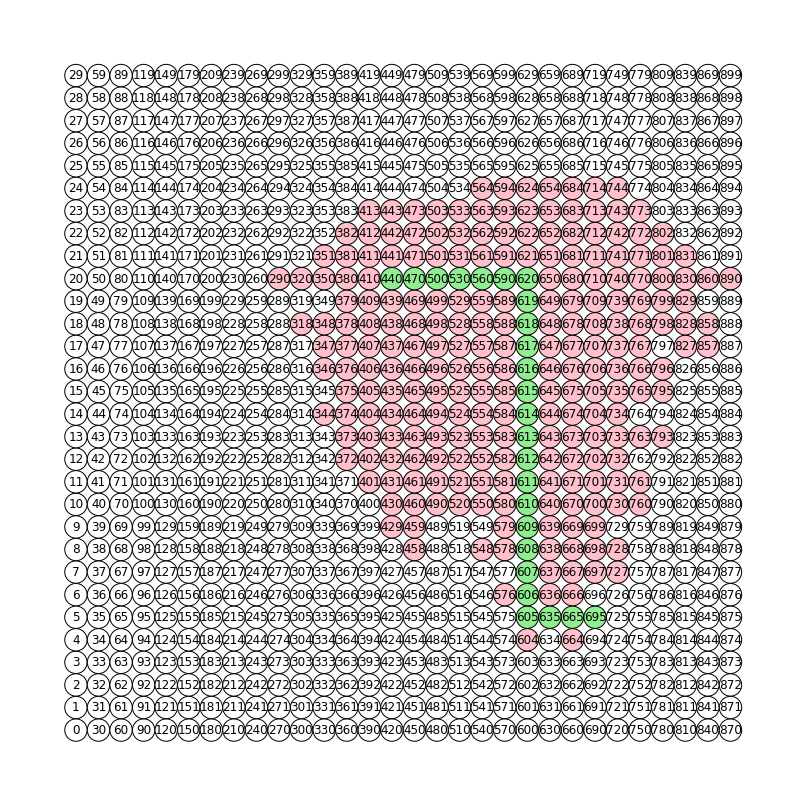

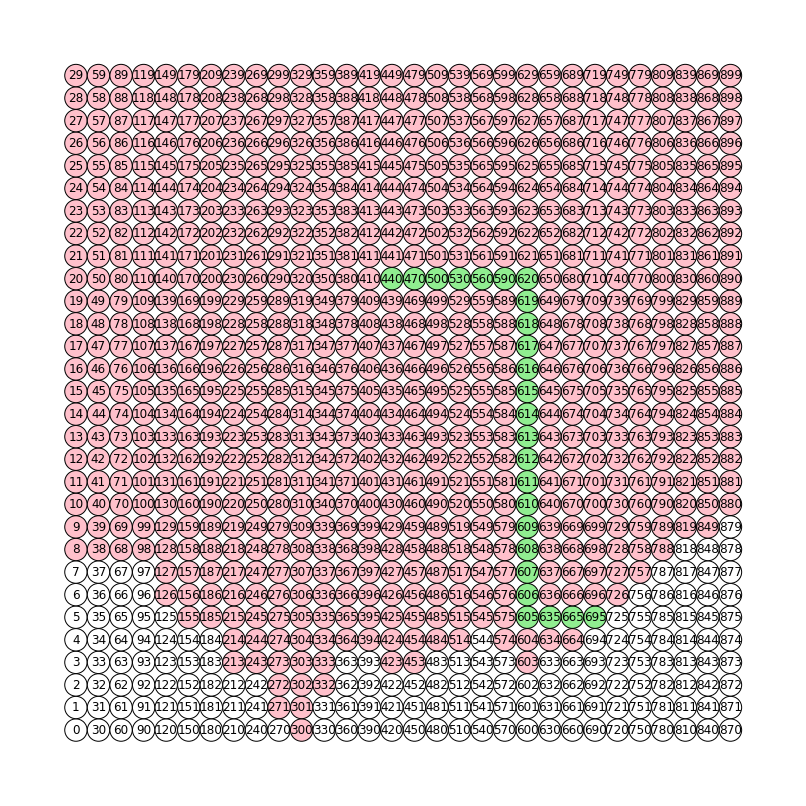

In [7]:
# Large road network example
import random

# id, coord
nodes = []
# i, j, trafficLevel, speedLimit (default: 50)
edges = []
# High-speed roads (80 km/h)
high_speed_roads = {
    "rows": {
        10: 80,
        20: 80
    },
    "cols": {
        10: 80,
        20: 80
    }
}
# Road network dimension
dim=30

for col in range(0,dim):
  for row in range(0,dim):
    id = row + col*dim
    coord = (col, row)
    nodes.append([id,coord])
  
    if col > 0:
      # If the current row is not a high-speed road, set speed limit to one of: 40, 50, 60, 70
      speedLimit = high_speed_roads["rows"].get(row, random.choice([40, 50, 60, 70]))
      edges.append([id, id-dim, random.uniform(1, 5), speedLimit])
    if row > 0:
      speedLimit = high_speed_roads["cols"].get(col, random.choice([40, 50, 60, 70]))
      edges.append([id, id-1, random.uniform(1, 2), speedLimit])
find_shortest_path(edges, nodes, 440, 695)

